# Notebook 2: Exploratory analysis of the dataset (EDA)

This notebook focuses on performing an Exploratory Data Analysis (EDA) on the Developer Survey Dataset. EDA is a crucial step in the data analysis process as it helps us understand the structure and characteristics of the dataset. By analyzing this dataset, we can uncover patterns, relationships, and potential insights that will guide further analysis, data cleaning, and decision-making. In this notebook, we will explore the dataset using various statistical and visualization techniques.

### Structure of the Notebook
- Setup: Import libraries and establish a database connection.
- Data Loading: Load the dataset from the `raw_survey` table.
- Dataset Overview: Examine the structure, data types, and basic statistics.
- Column Analysis: Focus on relevant columns, analyzing unique values and null counts.
- Distribution Analysis: Visualize distributions of key variables (enhancing existing visuals where possible).
- Relationship Analysis: Explore relationships between variables (preserving and improving your friend’s heatmap).
- Conclusions and Next Steps: Summarize findings and recommend transformations for data cleaning.

## Setup

We import necessary libraries for data manipulation and visualization, set up the plotting style, and establish a connection to the PostgreSQL database.

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

load_dotenv()
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_NAME = os.getenv('DB_NAME', 'dev_survey_insights')
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)
print(f"Connected to database: {DB_NAME} at {DB_HOST}:{DB_PORT}")

Connected to database: dev_survey_insights at localhost:5432


## Load Data

We load the full dataset from the `raw_survey` table in the PostgreSQL database into a Pandas DataFrame for analysis.

In [73]:
query = "SELECT * FROM raw_survey"
df = pd.read_sql(query, engine)
print(f"Data loaded successfully. Rows: {len(df)}, Columns: {len(df.columns)}")

Data loaded successfully. Rows: 98855, Columns: 129


## Dataset Overview

We examine the dataset's structure, data types, and basic statistics to get an initial understanding.

In [74]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98855 entries, 0 to 98854
Columns: 129 entries, Respondent to SurveyEasy
dtypes: float64(41), int64(1), object(87)
memory usage: 97.3+ MB


,Respondent,AssessJob1,AssessJob2,AssessJob3,AssessJob4,AssessJob5,AssessJob6,AssessJob7,AssessJob8,AssessJob9,...,JobEmailPriorities6,JobEmailPriorities7,ConvertedSalary,AdsPriorities1,AdsPriorities2,AdsPriorities3,AdsPriorities4,AdsPriorities5,AdsPriorities6,AdsPriorities7
count,98855.000000,66985.000000,66985.000000,66985.000000,66985.000000,66985.000000,66985.000000,66985.000000,66985.000000,66985.000000,...,46213.00000,46213.000000,4.770200e+04,60479.000000,60479.000000,60479.000000,60479.000000,60479.000000,60479.000000,60479.000000
mean,50822.971635,6.397089,6.673524,5.906875,4.065791,3.953243,4.407196,5.673181,4.225200,7.640009,...,4.97425,4.836388,9.578086e+04,2.726880,3.805784,3.340945,3.782470,4.383604,5.138809,4.821459
std,29321.650410,2.788428,2.531202,2.642734,2.541196,2.520499,2.502069,2.923998,2.507411,2.407457,...,1.86063,1.659844,2.023482e+05,1.881078,1.821323,1.673485,1.844864,1.931746,1.853249,1.874895
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.00000,1.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,25443.500000,4.000000,5.000000,4.000000,2.000000,2.000000,2.000000,3.000000,2.000000,6.000000,...,4.00000,4.000000,2.384400e+04,1.000000,2.000000,2.000000,2.000000,3.000000,4.000000,3.000000
50%,50823.000000,7.000000,7.000000,6.000000,4.000000,3.000000,4.000000,6.000000,4.000000,8.000000,...,5.00000,5.000000,5.507500e+04,2.000000,4.000000,3.000000,4.000000,5.000000,6.000000,5.000000
75%,76219.500000,9.000000,9.000000,8.000000,6.000000,6.000000,6.000000,8.000000,6.000000,10.000000,...,7.00000,6.000000,9.300000e+04,4.000000,5.000000,5.000000,5.000000,6.000000,7.000000,7.000000
max,101592.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,7.00000,7.000000,2.000000e+06,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000


## Column Analysis

We focus on a subset of relevant columns to analyze their unique values, null counts, and potential cleaning needs. These columns are grouped into categories for clarity.

In [75]:
print("Total number of columns:", len(df.columns))
print("Available columns:\n", df.columns.tolist())

Total number of columns: 129
Available columns:
 ['Respondent', 'Hobby', 'OpenSource', 'Country', 'Student', 'Employment', 'FormalEducation', 'UndergradMajor', 'CompanySize', 'DevType', 'YearsCoding', 'YearsCodingProf', 'JobSatisfaction', 'CareerSatisfaction', 'HopeFiveYears', 'JobSearchStatus', 'LastNewJob', 'AssessJob1', 'AssessJob2', 'AssessJob3', 'AssessJob4', 'AssessJob5', 'AssessJob6', 'AssessJob7', 'AssessJob8', 'AssessJob9', 'AssessJob10', 'AssessBenefits1', 'AssessBenefits2', 'AssessBenefits3', 'AssessBenefits4', 'AssessBenefits5', 'AssessBenefits6', 'AssessBenefits7', 'AssessBenefits8', 'AssessBenefits9', 'AssessBenefits10', 'AssessBenefits11', 'JobContactPriorities1', 'JobContactPriorities2', 'JobContactPriorities3', 'JobContactPriorities4', 'JobContactPriorities5', 'JobEmailPriorities1', 'JobEmailPriorities2', 'JobEmailPriorities3', 'JobEmailPriorities4', 'JobEmailPriorities5', 'JobEmailPriorities6', 'JobEmailPriorities7', 'UpdateCV', 'Currency', 'Salary', 'SalaryType', 'Co

In [76]:

df.AssessJob1.value_counts().head(10)

#df['AssessJob1'].isnull().sum()
#df['AssessJob1'].isnull().mean() * 100

#df.AssessJob1.unique()

AssessJob1
9.0     10200
8.0      9359
10.0     9163
7.0      8186
6.0      6841
5.0      5676
1.0      4981
4.0      4635
3.0      4070
2.0      3874
Name: count, dtype: int64

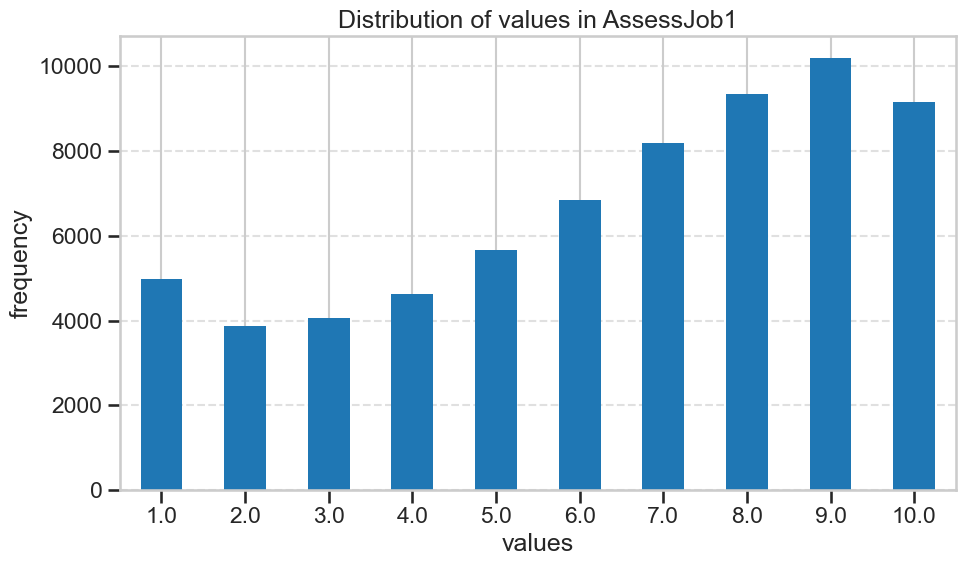

In [77]:
df['AssessJob1'].value_counts().sort_index().plot(kind='bar', figsize=(10,6))
plt.title('Distribution of values in AssessJob1')
plt.xlabel('values')
plt.ylabel('frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

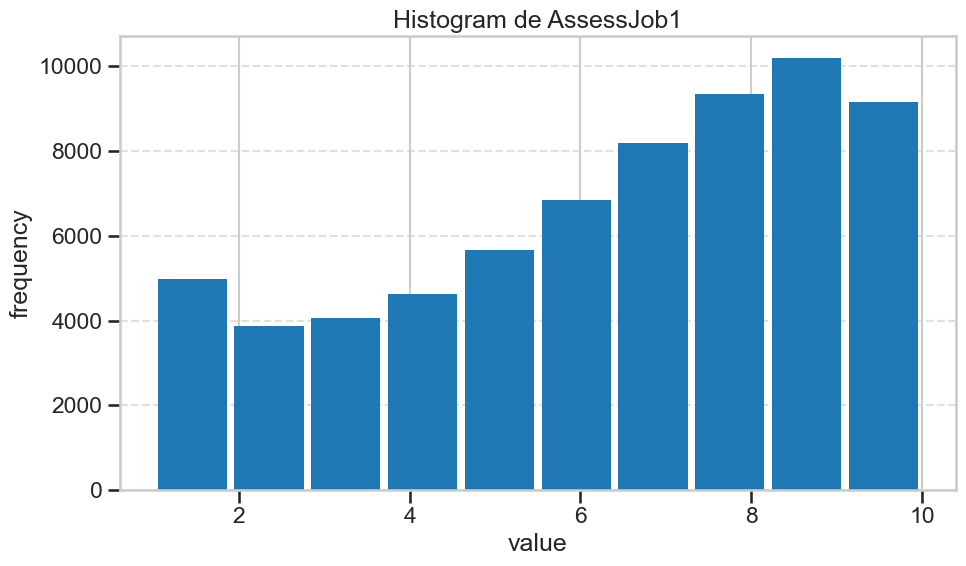

In [78]:
df['AssessJob1'].plot(kind='hist', bins=10, rwidth=0.9, figsize=(10,6))
plt.title('Histogram de AssessJob1')
plt.xlabel('value')
plt.ylabel('frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


with this information we can see the people don't important the industry to work is more importan other things like salay o similar

In [79]:
df.UndergradMajor.value_counts().head(100)

UndergradMajor
Computer science, computer engineering, or software engineering          50336
Another engineering discipline (ex. civil, electrical, mechanical)        6945
Information systems, information technology, or system administration     6507
A natural science (ex. biology, chemistry, physics)                       3050
Mathematics or statistics                                                 2818
Web development or web design                                             2418
A business discipline (ex. accounting, finance, marketing)                1921
A humanities discipline (ex. literature, history, philosophy)             1590
A social science (ex. anthropology, psychology, political science)        1377
Fine arts or performing arts (ex. graphic design, music, studio art)      1135
I never declared a major                                                   693
A health science (ex. nursing, pharmacy, radiology)                        246
Name: count, dtype: int64

In [80]:
df['UndergradMajor'].isnull().sum()
df['UndergradMajor'].isnull().mean() * 100

20.048555965808507

In [81]:
df['UndergradMajor'].fillna('Other')

0                                Mathematics or statistics
1        A natural science (ex. biology, chemistry, phy...
2        Computer science, computer engineering, or sof...
3        Computer science, computer engineering, or sof...
4        Computer science, computer engineering, or sof...
                               ...                        
98850                                                Other
98851                                                Other
98852                                                Other
98853                                                Other
98854                                                Other
Name: UndergradMajor, Length: 98855, dtype: object

In [82]:
df.UndergradMajor.value_counts().head(100)

UndergradMajor
Computer science, computer engineering, or software engineering          50336
Another engineering discipline (ex. civil, electrical, mechanical)        6945
Information systems, information technology, or system administration     6507
A natural science (ex. biology, chemistry, physics)                       3050
Mathematics or statistics                                                 2818
Web development or web design                                             2418
A business discipline (ex. accounting, finance, marketing)                1921
A humanities discipline (ex. literature, history, philosophy)             1590
A social science (ex. anthropology, psychology, political science)        1377
Fine arts or performing arts (ex. graphic design, music, studio art)      1135
I never declared a major                                                   693
A health science (ex. nursing, pharmacy, radiology)                        246
Name: count, dtype: int64

In [83]:
df.CommunicationTools.value_counts().head(100)

CommunicationTools
Office / productivity suite (Microsoft Office, Google Suite, etc.)                                      3523
Slack                                                                                                   3391
Confluence;Jira;Slack                                                                                   2256
Other chat system (IRC, proprietary software, etc.)                                                     1444
Jira;Slack                                                                                              1402
                                                                                                        ... 
Stack Overflow Enterprise                                                                                115
Google Hangouts/Chat;Office / productivity suite (Microsoft Office, Google Suite, etc.);Slack;Trello     115
Jira;Slack;Other chat system (IRC, proprietary software, etc.)                                           111


In [84]:
df['CommunicationTools'].str.split(';').explode().str.strip().value_counts().head(10)


CommunicationTools
Slack                                                                 29483
Jira                                                                  23692
Office / productivity suite (Microsoft Office, Google Suite, etc.)    22416
Other wiki tool (Github, Google Sites, proprietary software, etc.)    17879
Confluence                                                            16987
Google Hangouts/Chat                                                  12361
Other chat system (IRC, proprietary software, etc.)                   12242
Trello                                                                10221
Facebook                                                               5671
HipChat                                                                3524
Name: count, dtype: int64

In [85]:
df['CommunicationTools'].fillna('Other')

0                                                    Slack
1        Confluence;Office / productivity suite (Micros...
2                                                    Other
3                                                    Other
4                                                    Other
                               ...                        
98850                                                Other
98851                                                Other
98852                                                Other
98853                                                Other
98854                                                Other
Name: CommunicationTools, Length: 98855, dtype: object

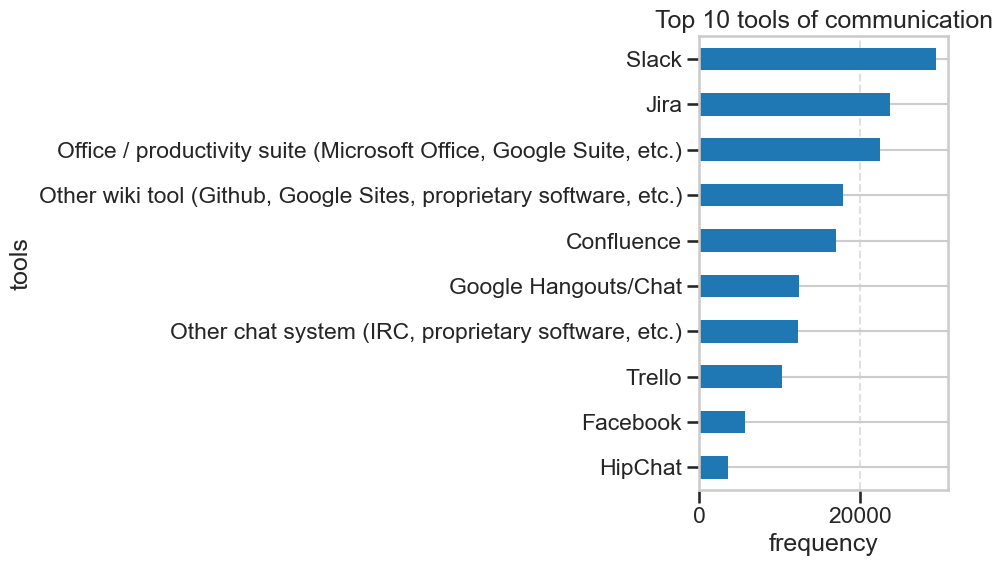

In [86]:
tool_counts = df['CommunicationTools'].dropna().str.split(';').explode().str.strip().value_counts().head(10)

tool_counts.plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 tools of communication')
plt.xlabel('frequency')
plt.ylabel('tools')
plt.gca().invert_yaxis()  
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [87]:
df.Hobby.head(10)
  

0    Yes
1    Yes
2    Yes
3     No
4     No
5    Yes
6    Yes
7    Yes
8    Yes
9    Yes
Name: Hobby, dtype: object

In [88]:
df.Hobby.value_counts().head()

Hobby
Yes    79897
No     18958
Name: count, dtype: int64

In [89]:
df.TimeFullyProductive.value_counts().head(10)

TimeFullyProductive
One to three months      23163
Less than a month        15579
Three to six months       9026
Six to nine months        2625
Nine months to a year      875
More than a year           604
Name: count, dtype: int64

In [90]:
df.TimeFullyProductive.isnull().sum()
df.TimeFullyProductive.isnull().mean() * 100

47.52718628293966

In [91]:
df.UpdateCV.value_counts().head(100)

UpdateCV
My job status or other personal status changed                      27344
A recruiter contacted me                                             9071
I had a negative experience or interaction at work                   7339
A friend told me about a job opportunity                             6997
I saw an employer’s advertisement                                    6756
I did not receive an expected change in compensation                 4362
I received bad news about the future of my company or department     3220
I received negative feedback on my job performance                    450
Name: count, dtype: int64

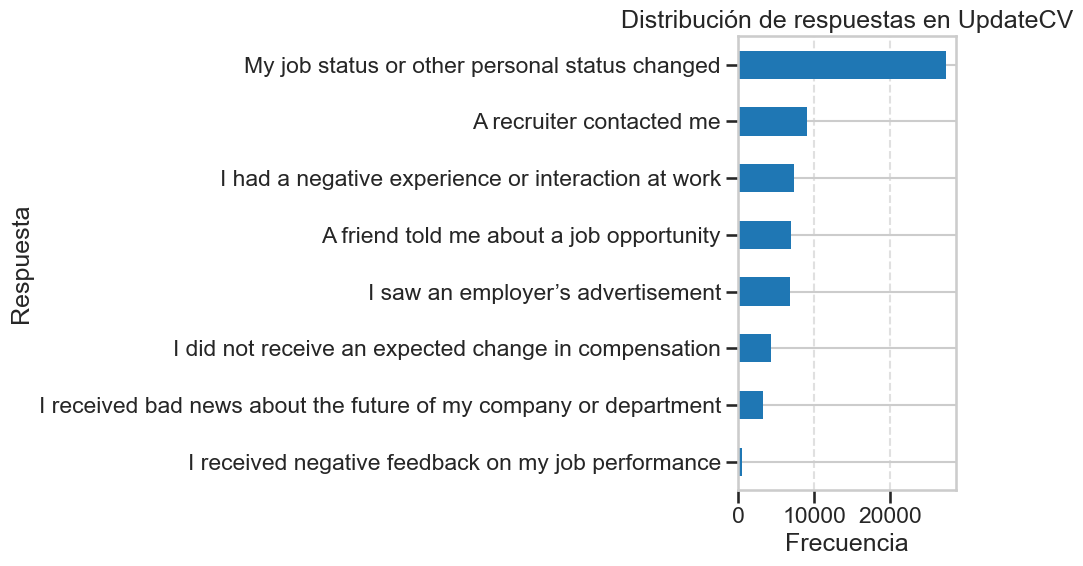

In [92]:
counts = df['UpdateCV'].value_counts()

counts.plot(kind='barh', figsize=(10, 6))
plt.title('Distribución de respuestas en UpdateCV')
plt.xlabel('Frecuencia')
plt.ylabel('Respuesta')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [93]:
df.Currency.value_counts().head(100)

Currency
U.S. dollars ($)               20601
Euros (€)                      15201
Indian rupees (₹)               7908
British pounds sterling (£)     4856
Canadian dollars (C$)           2535
Russian rubles (₽)              1768
Brazilian reais (R$)            1663
Australian dollars (A$)         1571
Polish złoty (zł)               1434
Swedish kroner (SEK)             864
Swiss francs                     671
Chinese yuan renminbi (¥)        512
Danish krone (kr)                461
Mexican pesos (MXN$)             457
South African rands (R)          432
Norwegian krone (kr)             423
Singapore dollars (S$)           263
Japanese yen (¥)                 241
Bitcoin (btc)                    147
Name: count, dtype: int64

In [94]:
df.Salary.value_counts().head(100)

Salary
0         1121
60000     1095
100000    1086
50000     1071
80000      888
          ... 
400        118
44000      118
92000      118
82000      116
2800       115
Name: count, Length: 100, dtype: int64

In [95]:
df.SalaryType.value_counts().head(100)

SalaryType
Monthly    26252
Yearly     22556
Weekly      2262
Name: count, dtype: int64

In [96]:
df.CurrencySymbol.value_counts().head(100)

CurrencySymbol
USD    17330
EUR    12781
INR     6633
GBP     4196
CAD     2122
       ...  
NIO        2
MVR        2
NAD        2
UZS        2
BTN        2
Name: count, Length: 100, dtype: int64

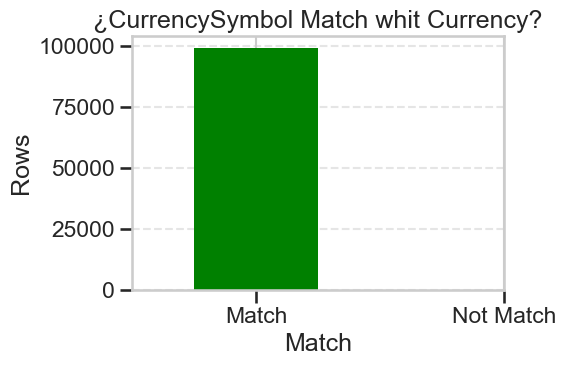

In [97]:
symbol_to_code = {
    '$': 'USD',
    '€': 'EUR',
    '₹': 'INR',
    '£': 'GBP',
    'C$': 'CAD',
    '₽': 'RUB',
    'R$': 'BRL',
    'A$': 'AUD',
    'zł': 'PLN',
    'kr': 'SEK',
    '¥': 'JPY',
    '₩': 'KRW',
    '₺': 'TRY',
    '₦': 'NGN',
    '฿': 'BTC'
    
}


df['MappedSymbol'] = df['CurrencySymbol'].map(symbol_to_code)


df['Match'] = df['MappedSymbol'] == df['Currency']


match_counts = df['Match'].value_counts()

match_counts.plot(kind='bar', color=['green', 'red'], figsize=(6,4))
plt.xticks([0,1], ['Match', 'Not Match'], rotation=0)
plt.title('¿CurrencySymbol Match whit Currency?')
plt.ylabel('Rows')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [98]:
df.NumberMonitors.value_counts().head()

NumberMonitors
2              39063
1              24362
3              10984
More than 4     1085
4                904
Name: count, dtype: int64

nada que ver pero el dato esta interesante

In [99]:
df['Methodology'].str.split(';').explode().str.strip().value_counts().head(10)


Methodology
Agile                                                                             50345
Scrum                                                                             36968
Kanban                                                                            20790
Pair programming                                                                  16728
Extreme programming (XP)                                                           9261
Formal standard such as ISO 9001 or IEEE 12207 (aka “waterfall” methodologies)     8879
Lean                                                                               5648
Evidence-based software engineering                                                2070
Mob programming                                                                    1953
PRINCE2                                                                             905
Name: count, dtype: int64

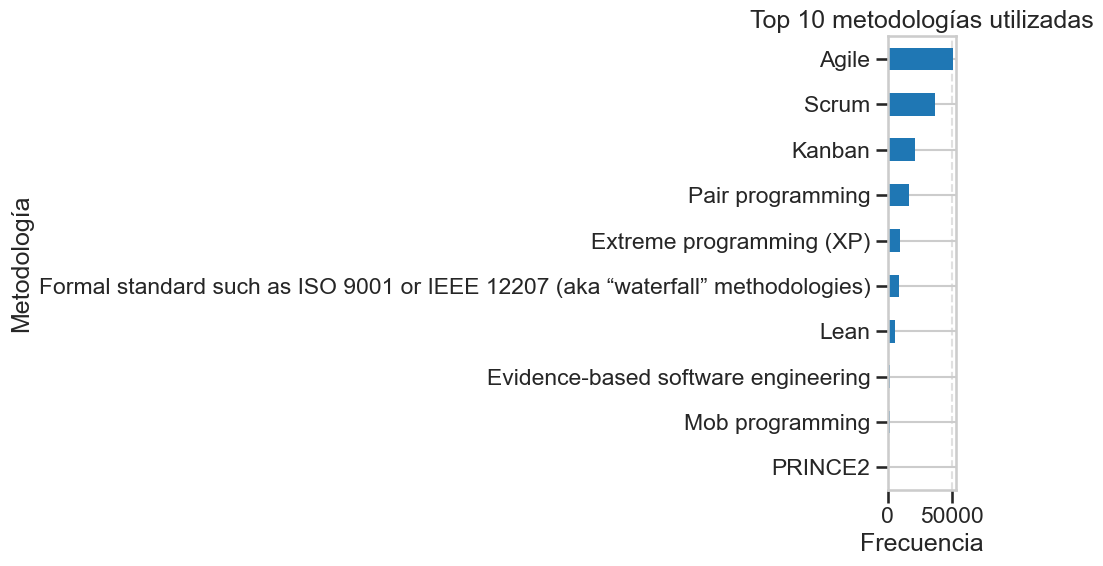

In [100]:
top_methods = (
    df['Methodology']
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

top_methods.plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 metodologías utilizadas')
plt.xlabel('Frecuencia')
plt.ylabel('Metodología')
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [101]:
df['VersionControl'].str.split(';').explode().str.strip().value_counts().head(10)


VersionControl
Git                                            64824
Subversion                                     11936
Team Foundation Version Control                 8067
Zip file back-ups                               5869
Copying and pasting files to network shares     5846
I don't use version control                     3562
Mercurial                                       2680
Name: count, dtype: int64

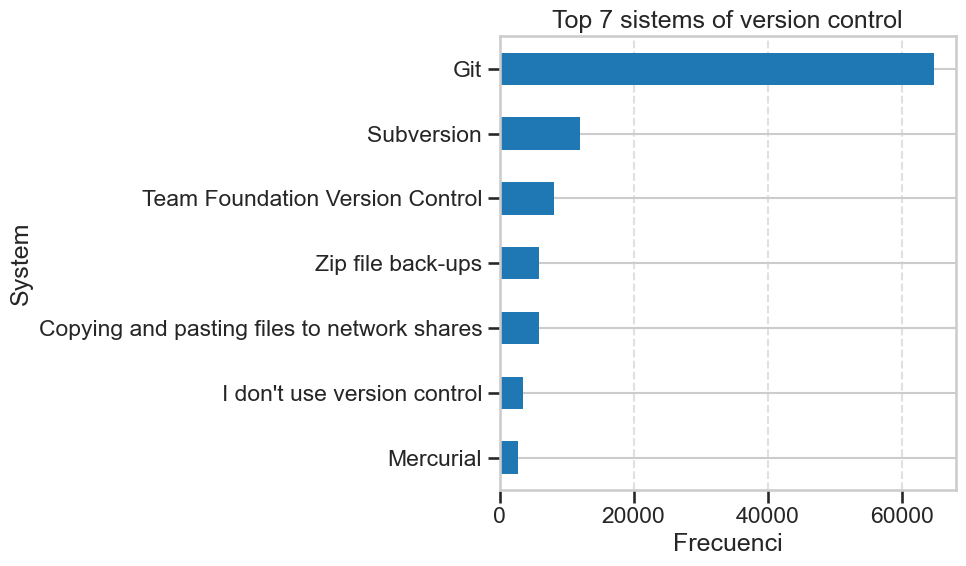

In [102]:
top_vcs = (
    df['VersionControl']
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts()
    .head(7)
)

top_vcs.plot(kind='barh', figsize=(10, 6))
plt.title('Top 7 sistems of version control')
plt.xlabel('Frecuenci')
plt.ylabel('System')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [103]:
df['IDE'].str.split(';').explode().str.strip().value_counts().head(10)


IDE
Visual Studio Code    26280
Visual Studio         25870
Notepad++             25755
Sublime Text          21810
Vim                   19477
IntelliJ              18765
Android Studio        14558
Eclipse               14213
Atom                  13576
PyCharm                9027
Name: count, dtype: int64

In [104]:
df.ConvertedSalary.value_counts().head(10)

ConvertedSalary
0.0          842
120000.0     524
100000.0     497
80000.0      396
1000000.0    382
110000.0     371
90000.0      364
150000.0     357
60000.0      351
75000.0      337
Name: count, dtype: int64

In [105]:
df.Employment.value_counts().head(100)

Employment
Employed full-time                                      70495
Independent contractor, freelancer, or self-employed     9282
Not employed, but looking for work                       5805
Employed part-time                                       5380
Not employed, and not looking for work                   4132
Retired                                                   227
Name: count, dtype: int64

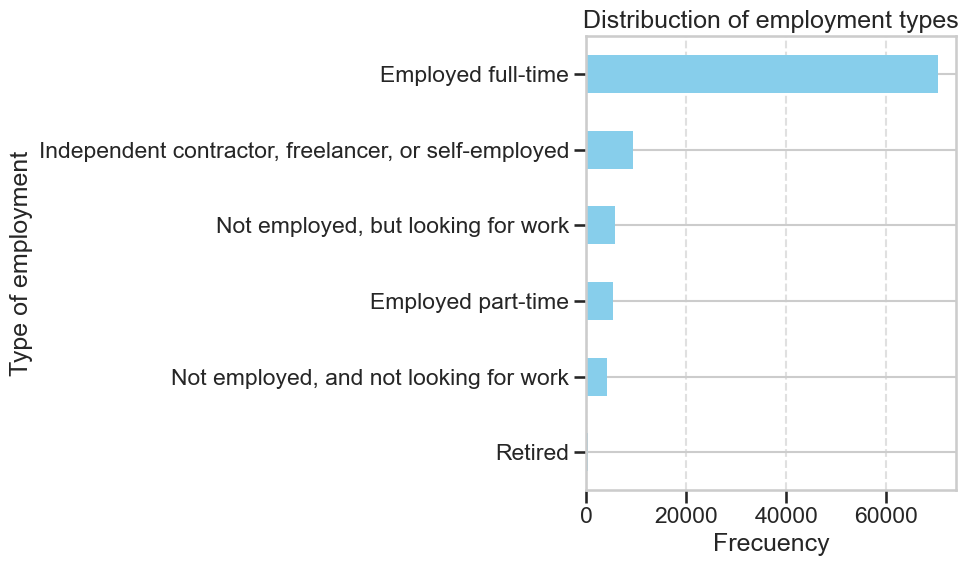

In [106]:
employment_counts = df['Employment'].value_counts()

employment_counts.plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Distribuction of employment types')
plt.xlabel('Frecuency')
plt.ylabel('Type of employment')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Keep Only the Relevant Columns
We define and select a subset of columns relevant to our analysis.

In [107]:
relevant_columns = [
    # Demographic
    'Country', 'Gender', 'Age', 'FormalEducation', 'RaceEthnicity',
    # Professional Experience
    'DevType', 'CompanySize', 'Employment', 'YearsCodingProf','UndergradMajor', 'UpdateCV',
    # Technologies and Tools
    'LanguageWorkedWith',  'DatabaseWorkedWith', 'PlatformWorkedWith',
    'FrameworkWorkedWith', 'IDE', 'OperatingSystem', 'CommunicationTools', 'Methodology', 'VersionControl',
    # Salary and Compensation
    'Salary', 'ConvertedSalary', 'SalaryType',  'Currency',
    # Job Satisfaction
    'JobSatisfaction', 'CareerSatisfaction', 'HopeFiveYears',
    # Miscellaneous
    'OpenSource', 'StackOverflowVisit', 'StackOverflowHasAccount',
    'StackOverflowParticipate', 'AIDangerous', 'AIInteresting',
    'AIResponsible', 'AIFuture', 'Hobby'
]

df_relevant = df[relevant_columns]
print("New DataFrame with relevant columns created. Shape:", df_relevant.shape)

New DataFrame with relevant columns created. Shape: (98855, 36)


Check for null values in relevant columns

In [108]:
print("Null counts for relevant columns:")
print(df_relevant.isnull().sum())

Null counts for relevant columns:
Country                       412
Gender                      34386
Age                         34281
FormalEducation              4152
RaceEthnicity               41382
DevType                      6757
CompanySize                 27324
Employment                   3534
YearsCodingProf             20952
UndergradMajor              19819
UpdateCV                    33316
LanguageWorkedWith          20521
DatabaseWorkedWith          32585
PlatformWorkedWith          32856
FrameworkWorkedWith         47235
IDE                         23457
OperatingSystem             22676
CommunicationTools          41885
Methodology                 39874
VersionControl              24557
Salary                      48277
ConvertedSalary             51153
SalaryType                  47785
Currency                    36847
JobSatisfaction             29579
CareerSatisfaction          22351
HopeFiveYears               23137
OpenSource                      0
StackOverflowV

Analyze unique values for key categorical columns

In [109]:
print("\nUnique values for categorical columns (sample):")
for col in ['Country', 'Gender', 'Age', 'FormalEducation', 'Employment']:
    unique_vals = df_relevant[col].unique()
    print(f"\n{col} ({len(unique_vals)} unique values):\n", unique_vals[:10])


Unique values for categorical columns (sample):

Country (184 unique values):
 ['Kenya' 'United Kingdom' 'United States' 'India' 'South Africa' 'Nigeria'
 'Spain' 'Croatia' 'Netherlands' 'Israel']

Gender (16 unique values):
 ['Male' None 'Female'
 'Female;Male;Transgender;Non-binary, genderqueer, or gender non-conforming'
 'Female;Male' 'Male;Non-binary, genderqueer, or gender non-conforming'
 'Non-binary, genderqueer, or gender non-conforming' 'Transgender'
 'Female;Transgender'
 'Transgender;Non-binary, genderqueer, or gender non-conforming']

Age (8 unique values):
 ['25 - 34 years old' '35 - 44 years old' None '18 - 24 years old'
 '45 - 54 years old' '55 - 64 years old' 'Under 18 years old'
 '65 years or older']

FormalEducation (10 unique values):
 ['Bachelor’s degree (BA, BS, B.Eng., etc.)' 'Associate degree'
 'Some college/university study without earning a degree'
 'Master’s degree (MA, MS, M.Eng., MBA, etc.)'
 'Secondary school (e.g. American high school, German Realschule o

## Distribution Analysis

### Geographic Distribution

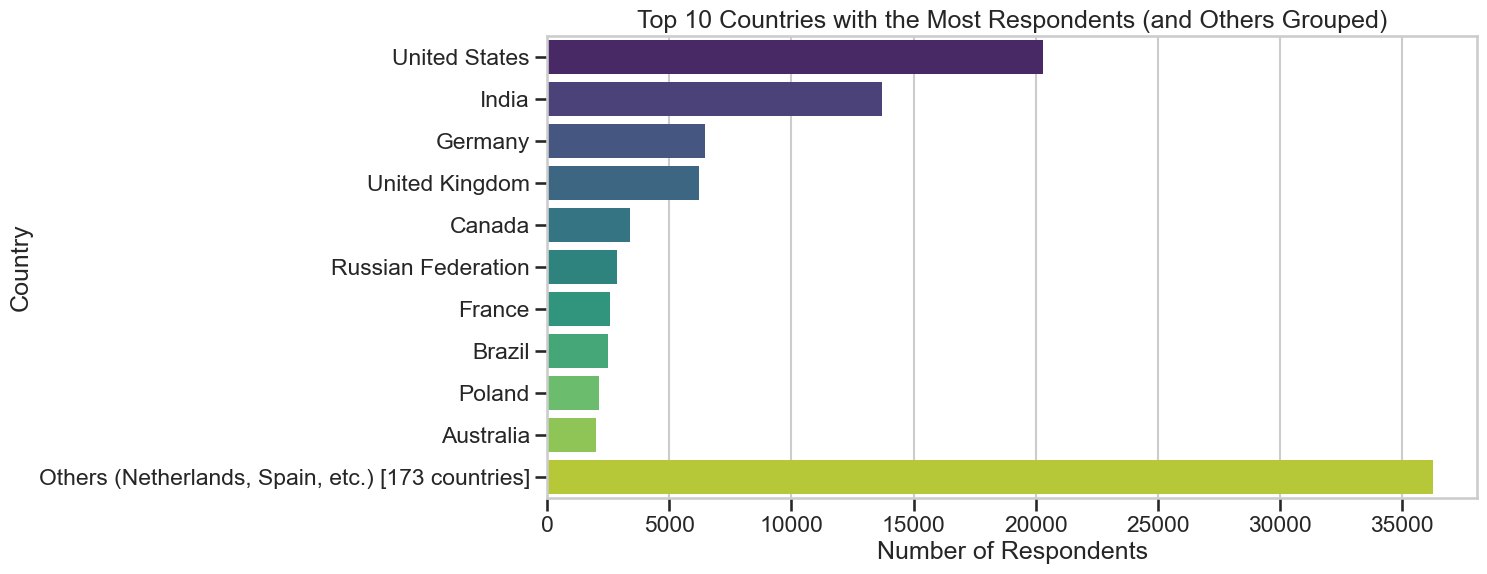

In [110]:
country_counts = df["Country"].value_counts()
top_10_countries = country_counts.head(10)
rest_countries = country_counts.iloc[10:]
sum_rest = rest_countries.sum()
others_count = len(rest_countries)

some_others = rest_countries.index[:2]
some_others_str = ", ".join(some_others) + ", etc."
other_label = f"Others ({some_others_str}) [{others_count} countries]"

top_10_countries = pd.concat([top_10_countries, pd.Series({other_label: sum_rest})])

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette="viridis")
plt.title("Top 10 Countries with the Most Respondents (and Others Grouped)")
plt.xlabel("Number of Respondents")
plt.ylabel("Country")
plt.show()

### Gender Distribution

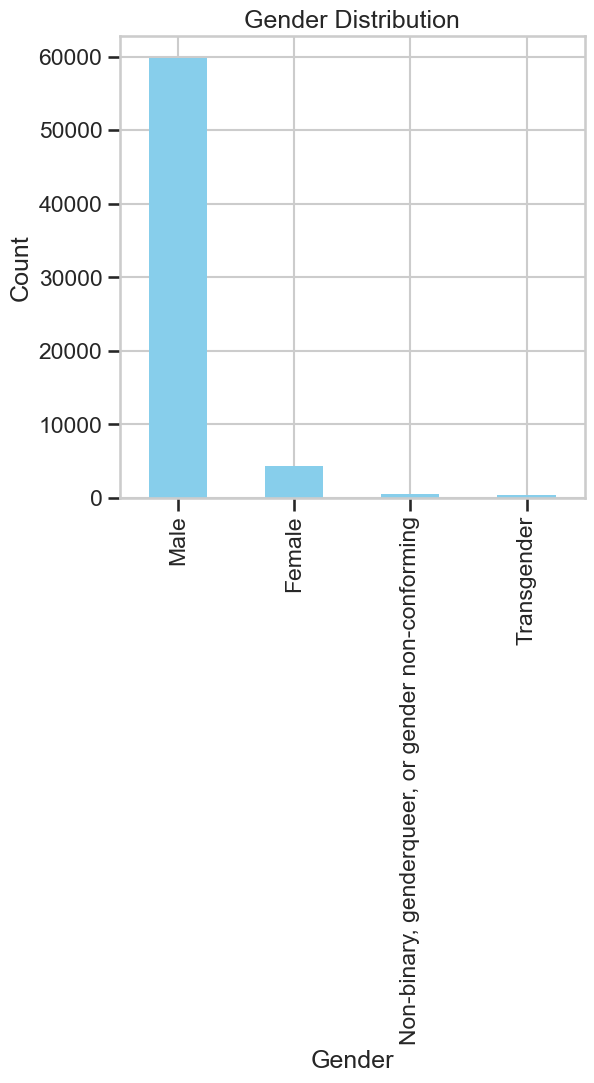

In [111]:
plt.figure(figsize=(6, 6))
gender_counts = df['Gender'].str.split(';').explode().str.strip().value_counts().head(10)

gender_counts.plot(kind="bar", color="skyblue")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### Age Distribution

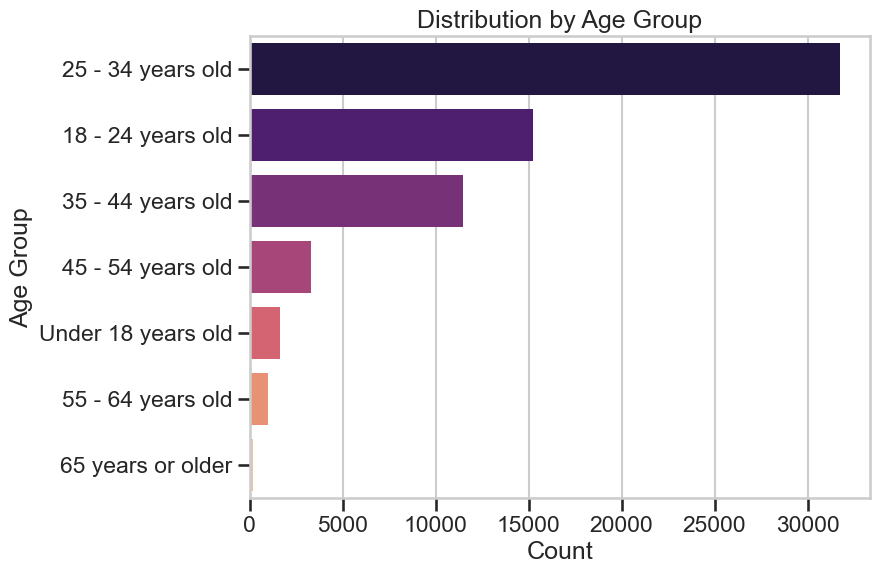

In [112]:
plt.figure(figsize=(8, 6))
age_counts = df["Age"].value_counts()
sns.barplot(x=age_counts.values, y=age_counts.index, palette="magma")
plt.title("Distribution by Age Group")
plt.xlabel("Count")
plt.ylabel("Age Group")
plt.show()

### Formal Education Level

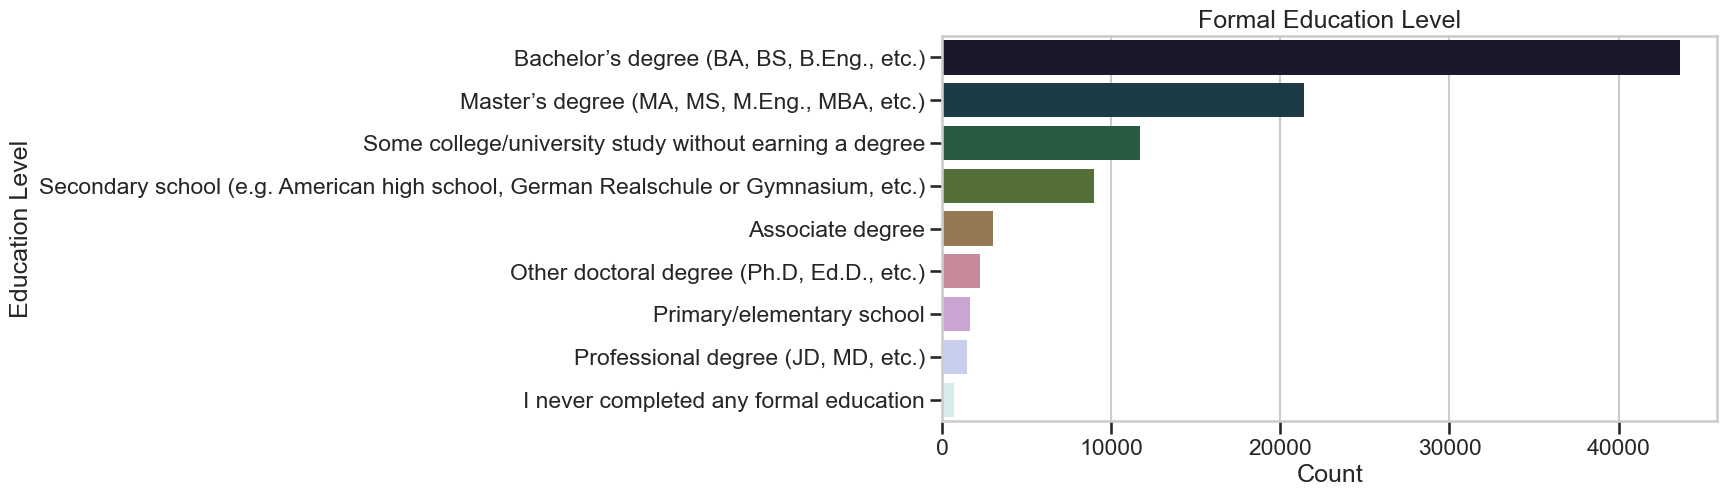

In [113]:
plt.figure(figsize=(10, 5))
edu_counts = df["FormalEducation"].value_counts()
sns.barplot(x=edu_counts.values, y=edu_counts.index, palette="cubehelix")
plt.title("Formal Education Level")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.show()

### Developer Types (DevType)

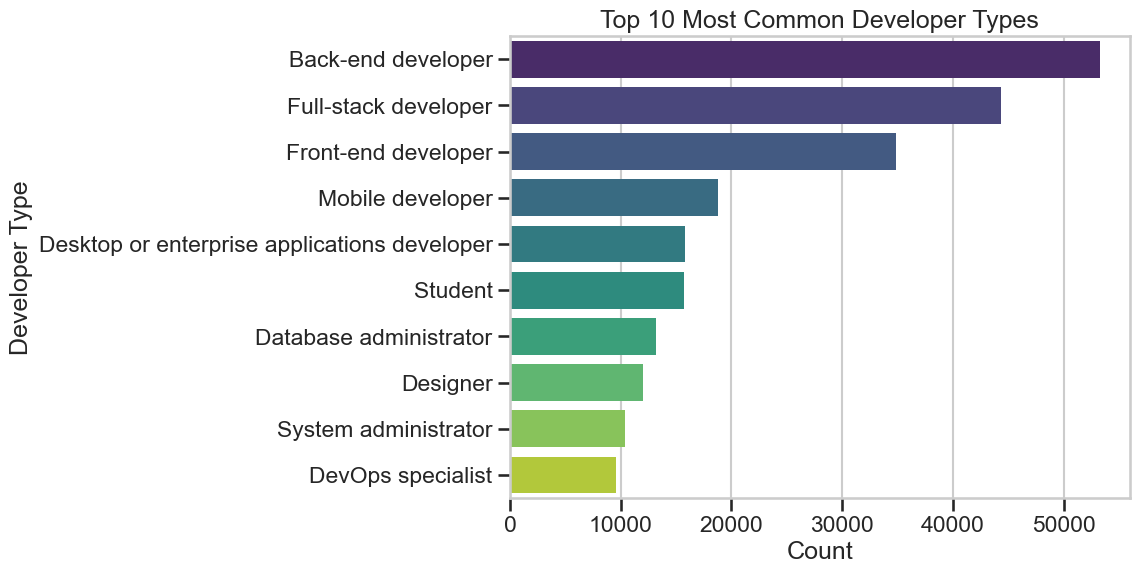

In [114]:
df_devtype = df["DevType"].dropna().str.split(";", expand=True).stack().reset_index(drop=True)
top_devtype = df_devtype.value_counts().head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_devtype.values, y=top_devtype.index, palette="viridis")
plt.title("Top 10 Most Common Developer Types")
plt.xlabel("Count")
plt.ylabel("Developer Type")
plt.show()

### Years Coding

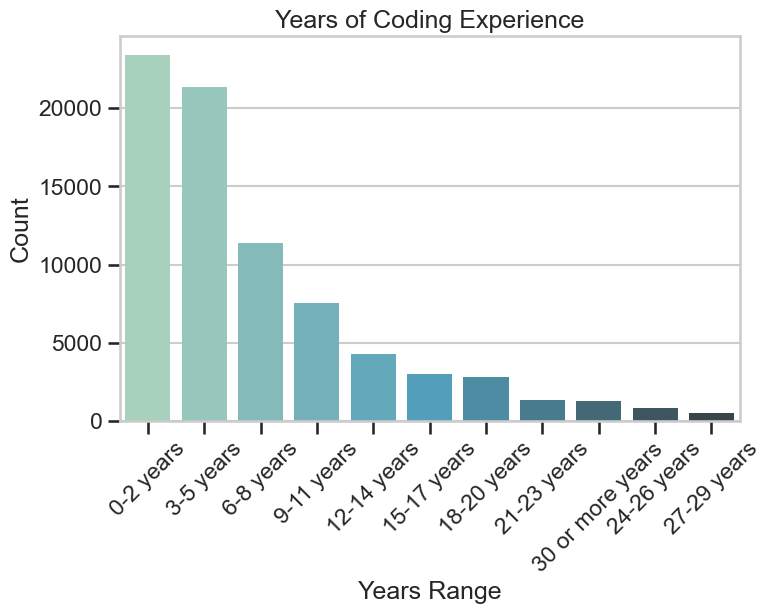

In [115]:
plt.figure(figsize=(8, 5))
yc_counts = df["YearsCodingProf"].value_counts()
sns.barplot(x=yc_counts.index, y=yc_counts.values, palette="GnBu_d")
plt.title("Years of Coding Experience")
plt.xlabel("Years Range")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Employment Status


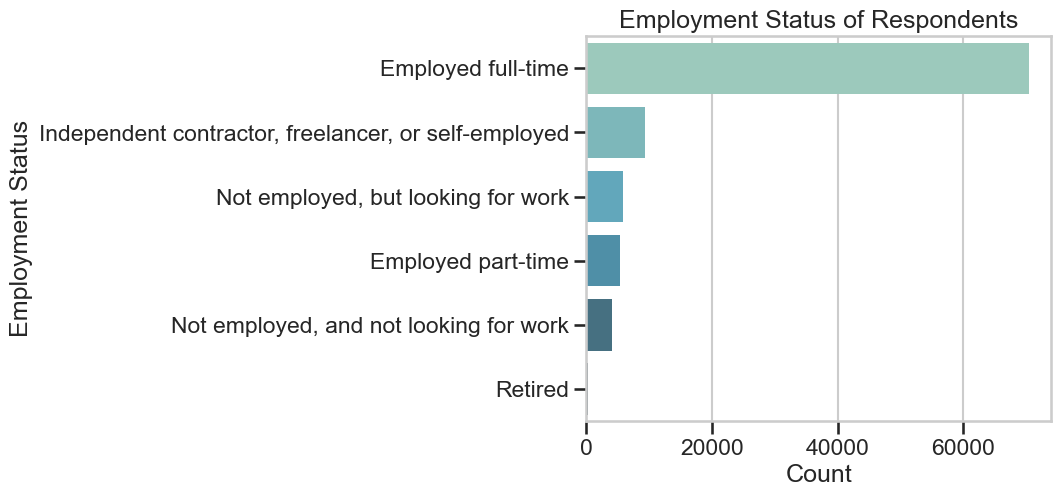

In [116]:
plt.figure(figsize=(6, 5))
employment_counts = df["Employment"].value_counts()
sns.barplot(y=employment_counts.index, x=employment_counts.values, palette="GnBu_d")
plt.title("Employment Status of Respondents")
plt.xlabel("Count")
plt.ylabel("Employment Status")
plt.show()

## Technologies and Tools

### Languages Worked With

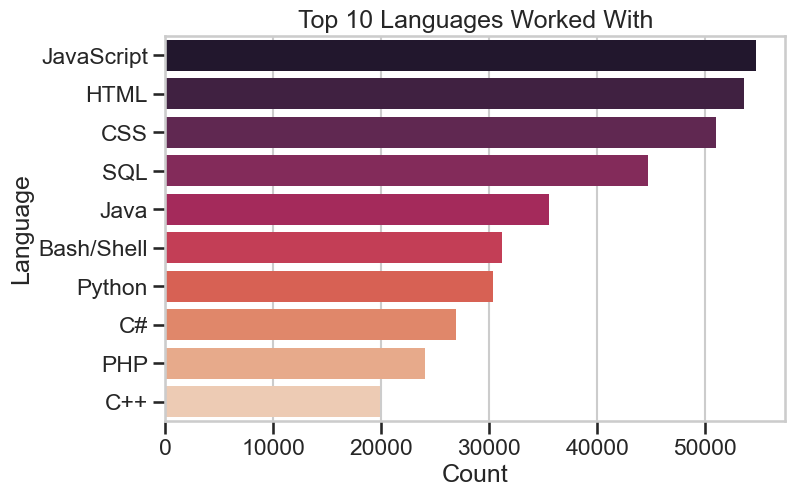

In [117]:
df_lang = df["LanguageWorkedWith"].dropna().str.split(";", expand=True).stack().reset_index(drop=True)
top_lang = df_lang.value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_lang.values, y=top_lang.index, palette="rocket")
plt.title("Top 10 Languages Worked With")
plt.xlabel("Count")
plt.ylabel("Language")
plt.show()

## Salary Analysis

### Distribution of Converted Salary

c:\Users\Nicolas Cuaran\Desktop\ETL\Proyecto Segunda entrega\DevSurveyInsights\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


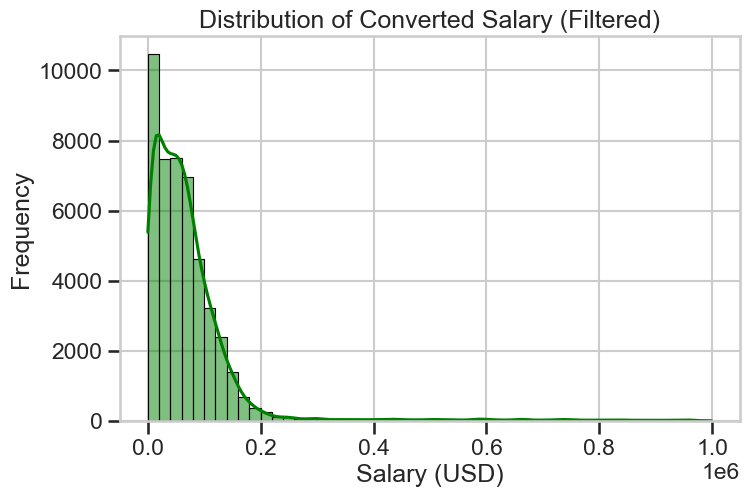

In [118]:
df_salary = df["ConvertedSalary"].dropna()
salary_99th = df_salary.quantile(0.99)
df_salary_filtered = df_salary[df_salary < salary_99th]

plt.figure(figsize=(8, 5))
sns.histplot(df_salary_filtered, kde=True, color="green", bins=50)
plt.title("Distribution of Converted Salary (Filtered)")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")
plt.show()

In [119]:
df.Salary.value_counts().head(100)

Salary
0         1121
60000     1095
100000    1086
50000     1071
80000      888
          ... 
400        118
44000      118
92000      118
82000      116
2800       115
Name: count, Length: 100, dtype: int64

### Salary Comparison by Country (Top 5)

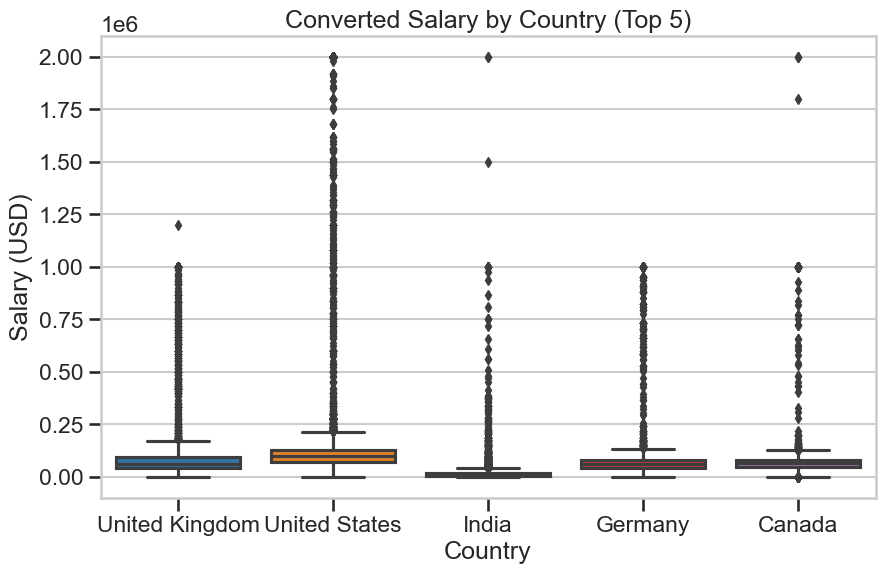

In [120]:
top_countries = df["Country"].value_counts().head(5).index
df_top_countries = df[df["Country"].isin(top_countries)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top_countries, x="Country", y="ConvertedSalary")
plt.title("Converted Salary by Country (Top 5)")
plt.xlabel("Country")
plt.ylabel("Salary (USD)")
plt.show()

In [121]:
# Tasa de conversión a COP aproximada en 2018
conversion_rates = {
    'U.S. dollars ($)': 2900,
    'Euros (€)': 3400,
    'Indian rupees (₹)': 40,
    'British pounds sterling (£)': 3800,
    'Canadian dollars (C$)': 2200,
    'Russian rubles (₽)': 50,
    'Brazilian reais (R$)': 800,
    'Australian dollars (A$)': 2200,
    'Polish złoty (zł)': 800,
    'Swedish kroner (SEK)': 350,
    'Swiss francs': 3100,
    'Chinese yuan renminbi (¥)': 420,
    'Danish krone (kr)': 500,
    'Mexican pesos (MXN$)': 150,
    'South African rands (R)': 220,
    'Norwegian krone (kr)': 400,
    'Singapore dollars (S$)': 2100,
    'Japanese yen (¥)': 25,
    'Bitcoin (btc)': 0
}

# Crear copia del DataFrame original
df_test_clean = df.copy()

# Asegurar que Salary sea numérico
df_test_clean['Salary'] = pd.to_numeric(df_test_clean['Salary'], errors='coerce')

# Filtrar registros válidos (positivos y con tipo/moneda reconocidos)
df_test_clean = df_test_clean[
    (df_test_clean['Salary'] > 0) &
    (df_test_clean['SalaryType'].isin(['Monthly', 'Yearly', 'Weekly'])) &
    (df_test_clean['Currency'].isin(conversion_rates.keys()))
]

# Convertir a salario mensual
def convertir_salario_mensual(row):
    if row['SalaryType'] == 'Yearly':
        return row['Salary'] / 12
    elif row['SalaryType'] == 'Weekly':
        return row['Salary'] * 4
    else:
        return row['Salary']

df_test_clean['MonthlySalary'] = df_test_clean.apply(convertir_salario_mensual, axis=1)

# Convertir a COP
def convertir_a_cop(row):
    tasa = conversion_rates.get(row['Currency'], 0)
    return round(row['MonthlySalary'] * tasa, 2) if tasa > 0 else 0

df_test_clean['StandardizedMonthlySalaryCOP'] = df_test_clean.apply(convertir_a_cop, axis=1)

# Eliminar valores extremos opcionalmente (ejemplo: mayores a 200 millones COP)
df_test_clean = df_test_clean[df_test_clean['StandardizedMonthlySalaryCOP'] <= 200_000_000]

# Ver resultados
print(df_test_clean[['Salary', 'SalaryType', 'Currency', 'MonthlySalary', 'StandardizedMonthlySalaryCOP']].head())


      Salary SalaryType                     Currency  MonthlySalary  \
1    51000.0     Yearly  British pounds sterling (£)    4250.000000   
6   260000.0     Yearly      South African rands (R)   21666.666667   
8   120000.0     Yearly             U.S. dollars ($)   10000.000000   
10  250000.0     Yearly             U.S. dollars ($)   20833.333333   
19   32000.0    Monthly         Swedish kroner (SEK)   32000.000000   

    StandardizedMonthlySalaryCOP  
1                    16150000.00  
6                     4766666.67  
8                    29000000.00  
10                   60416666.67  
19                   11200000.00  


In [122]:
df_test_clean.StandardizedMonthlySalaryCOP.describe()

count    3.571600e+04
mean     1.746437e+07
std      2.263804e+07
min      0.000000e+00
25%      5.733200e+06
50%      1.266667e+07
75%      2.125000e+07
max      2.000000e+08
Name: StandardizedMonthlySalaryCOP, dtype: float64

In [123]:
df.Currency.value_counts().head(100)

Currency
U.S. dollars ($)               20601
Euros (€)                      15201
Indian rupees (₹)               7908
British pounds sterling (£)     4856
Canadian dollars (C$)           2535
Russian rubles (₽)              1768
Brazilian reais (R$)            1663
Australian dollars (A$)         1571
Polish złoty (zł)               1434
Swedish kroner (SEK)             864
Swiss francs                     671
Chinese yuan renminbi (¥)        512
Danish krone (kr)                461
Mexican pesos (MXN$)             457
South African rands (R)          432
Norwegian krone (kr)             423
Singapore dollars (S$)           263
Japanese yen (¥)                 241
Bitcoin (btc)                    147
Name: count, dtype: int64

In [124]:
# Ver todas las monedas no reconocidas
monedas_desconocidas = df[~df['Currency'].isin(conversion_rates.keys())]['Currency'].value_counts()
print("Monedas no reconocidas (top):")
print(monedas_desconocidas.head(20))


Monedas no reconocidas (top):
Series([], Name: count, dtype: int64)


now whit the real dataframe 

In [125]:
conversion_rates = {
    'U.S. dollars ($)': 2900,
    'Euros (€)': 3400,
    'Indian rupees (₹)': 40,
    'British pounds sterling (£)': 3800,
    'Canadian dollars (C$)': 2200,
    'Russian rubles (₽)': 50,
    'Brazilian reais (R$)': 800,
    'Australian dollars (A$)': 2200,
    'Polish złoty (zł)': 800,
    'Swedish kroner (SEK)': 350,
    'Swiss francs': 3100,
    'Chinese yuan renminbi (¥)': 420,
    'Danish krone (kr)': 500,
    'Mexican pesos (MXN$)': 150,
    'South African rands (R)': 220,
    'Norwegian krone (kr)': 400,
    'Singapore dollars (S$)': 2100,
    'Japanese yen (¥)': 25,
    'Bitcoin (btc)': 0
}

# Asegurar tipo numérico
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')

# Crear máscara con registros válidos para procesar
valid_mask = (
    (df['Salary'] > 0) &
    (df['SalaryType'].isin(['Monthly', 'Yearly', 'Weekly'])) &
    (df['Currency'].isin(conversion_rates.keys()))
)

# Filtrar registros válidos
df_valid = df[valid_mask].copy()

# Convertir a salario mensual
def convertir_salario_mensual(row):
    if row['SalaryType'] == 'Yearly':
        return row['Salary'] / 12
    elif row['SalaryType'] == 'Weekly':
        return row['Salary'] * 4
    else:
        return row['Salary']

df_valid['MonthlySalary'] = df_valid.apply(convertir_salario_mensual, axis=1)

# Convertir a COP
def convertir_a_cop(row):
    tasa = conversion_rates.get(row['Currency'], 0)
    return round(row['MonthlySalary'] * tasa, 2) if tasa > 0 else 0

df_valid['StandardizedMonthlySalaryCOP'] = df_valid.apply(convertir_a_cop, axis=1)

# Eliminar valores extremos (> 200 millones COP/mes)
df_valid.loc[df_valid['StandardizedMonthlySalaryCOP'] > 200_000_000, 'StandardizedMonthlySalaryCOP'] = None

# Integrar al DataFrame original (solo en los índices válidos)
df['StandardizedMonthlySalaryCOP'] = None
df.loc[df_valid.index, 'StandardizedMonthlySalaryCOP'] = df_valid['StandardizedMonthlySalaryCOP']


In [126]:
df.StandardizedMonthlySalaryCOP.isnull().sum()

63139

In [127]:
# Cuántos tienen Salary faltante o inválido
print("Salary inválido:", df['Salary'].isna().sum(), " | <= 0:", (df['Salary'] <= 0).sum())

# Cuántos tienen SalaryType no reconocido
print("SalaryType desconocido:", (~df['SalaryType'].isin(['Monthly', 'Yearly', 'Weekly'])).sum())

# Cuántos tienen Currency no reconocido
print("Currency desconocido:", (~df['Currency'].isin(conversion_rates.keys())).sum())

# Cuántos fueron descartados por exceso de salario
print("Descartados por >200M COP:", (df['StandardizedMonthlySalaryCOP'] > 200_000_000).sum())


Salary inválido: 48528  | <= 0: 1154
SalaryType desconocido: 47785
Currency desconocido: 36847
Descartados por >200M COP: 0


In [128]:
# Ver los tipos de salario no reconocidos
tipos_salario_desconocidos = df[~df['SalaryType'].isin(['Monthly', 'Yearly', 'Weekly'])]['SalaryType'].value_counts()
print(tipos_salario_desconocidos)


Series([], Name: count, dtype: int64)


In [129]:
print("SalaryType nulos:", df['SalaryType'].isna().sum())


SalaryType nulos: 47785


In [130]:
df['StandardizedMonthlySalaryCOP'].fillna(0, inplace=True)


In [131]:
print("Valores nulos restantes:", df['StandardizedMonthlySalaryCOP'].isnull().sum())


Valores nulos restantes: 0


lo que se hizo fue acomodar los nulos commo 0 y se pueden interpretar como prefiero no decirlo 
se hicieron varias transformaciones pero en general fue eso ya que salary y salary type tienen muchos valores nulos entonces mejor asi lo podemos analizar 

## Job Satisfaction Analysis

### Job Satisfaction

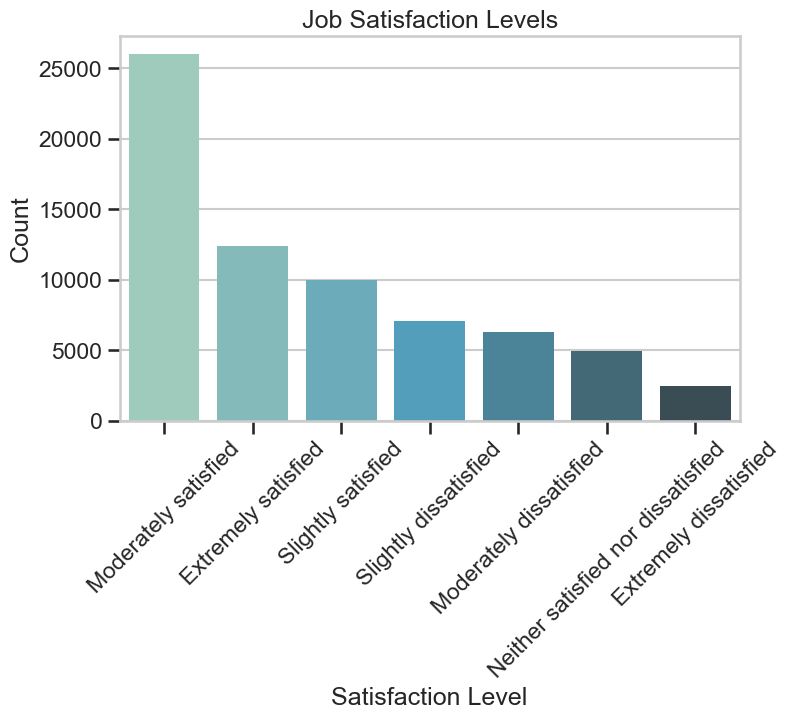

In [132]:
plt.figure(figsize=(8, 5))
job_sat_counts = df["JobSatisfaction"].value_counts()
sns.barplot(x=job_sat_counts.index, y=job_sat_counts.values, palette="GnBu_d")
plt.title("Job Satisfaction Levels")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Career Satisfaction

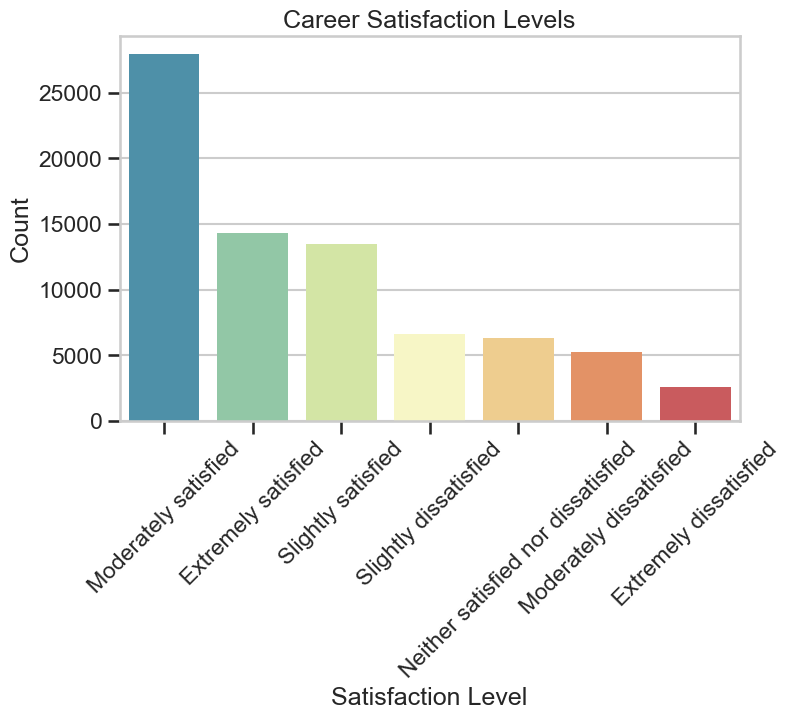

In [133]:
plt.figure(figsize=(8, 5))
career_sat_counts = df["CareerSatisfaction"].value_counts()
sns.barplot(x=career_sat_counts.index, y=career_sat_counts.values, palette="Spectral_r")
plt.title("Career Satisfaction Levels")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Relationship Analysis

### Heatmap: Top 5 Developer Types vs. Top 5 Languages

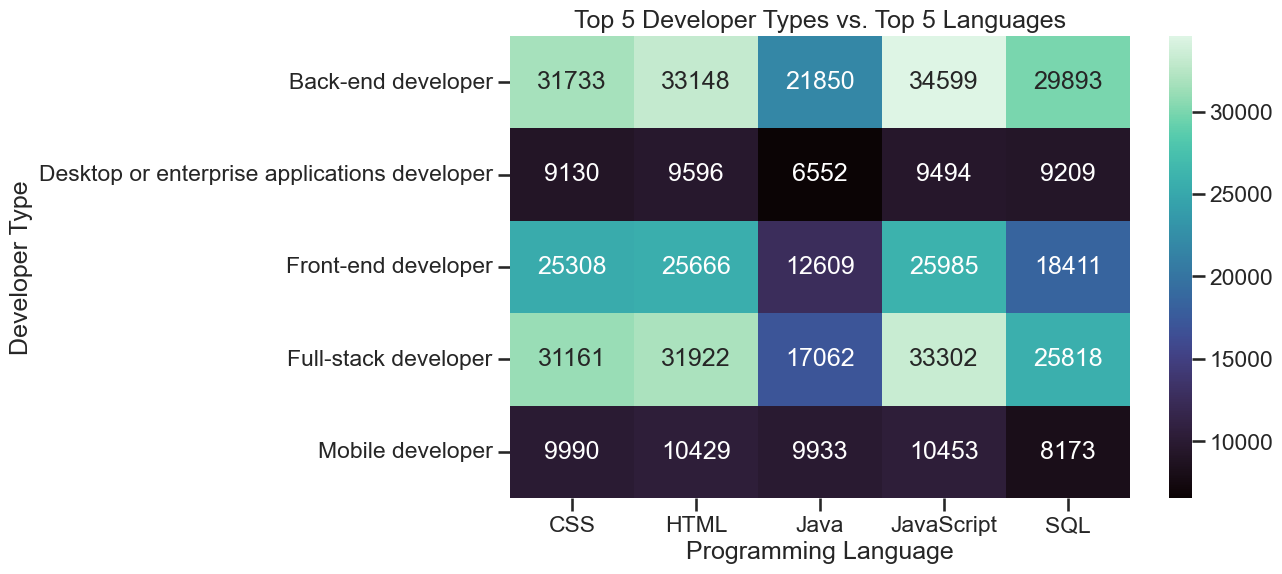

In [134]:
dev_lang_df = df_relevant[['DevType', 'LanguageWorkedWith']].dropna()
dev_lang_df = dev_lang_df.assign(
    DevType=dev_lang_df['DevType'].str.split(';'),
    LanguageWorkedWith=dev_lang_df['LanguageWorkedWith'].str.split(';')
).explode('DevType').explode('LanguageWorkedWith')

top_5_dev = dev_lang_df['DevType'].value_counts().head(5).index
top_5_lang = dev_lang_df['LanguageWorkedWith'].value_counts().head(5).index
filtered_df = dev_lang_df[dev_lang_df['DevType'].isin(top_5_dev) & dev_lang_df['LanguageWorkedWith'].isin(top_5_lang)]

pivot_df = filtered_df.pivot_table(index='DevType', columns='LanguageWorkedWith', aggfunc='size', fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='mako')
plt.title('Top 5 Developer Types vs. Top 5 Languages')
plt.xlabel('Programming Language')
plt.ylabel('Developer Type')
plt.show()

In [135]:
df.HopeFiveYears.value_counts().head(100)

HopeFiveYears
Working in a different or more specialized technical role than the one I'm in now    25643
Working as a founder or co-founder of my own company                                 19444
Doing the same work                                                                  14724
Working as an engineering manager or other functional manager                         7483
Working as a product manager or project manager                                       5004
Working in a career completely unrelated to software development                      2151
Retirement                                                                            1269
Name: count, dtype: int64

In [136]:
# Paso 1: Lista de columnas relevantes
benefit_cols = [
    'AssessBenefits2', 'AssessBenefits3', 'AssessBenefits4', 'AssessBenefits5',
    'AssessBenefits7', 'AssessBenefits8', 'AssessBenefits9',
    'AssessBenefits10', 'AssessBenefits11'
]

# Paso 2: Asegurar tipo entero en cada columna (con soporte para nulos)
df[benefit_cols] = df[benefit_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

# Paso 3: Calcular promedio por fila y redondear al entero más cercano
df['AvgNonSalaryBenefitsImportance'] = df[benefit_cols].mean(axis=1).round().astype('Int64')

# Paso 4: Verifica
print(df['AvgNonSalaryBenefitsImportance'].value_counts().sort_index())

AvgNonSalaryBenefitsImportance
5     1105
6    29460
7    34353
Name: count, dtype: Int64


In [137]:
df.AvgNonSalaryBenefitsImportance.value_counts().head(100)

AvgNonSalaryBenefitsImportance
7    34353
6    29460
5     1105
Name: count, dtype: Int64

In [138]:
# Paso 1: Definir columnas de interés
contacto_fuera_horario_cols = [
    'JobEmailPriorities1',
    'JobEmailPriorities2',
    'JobEmailPriorities3',
    'JobEmailPriorities6',
    'JobEmailPriorities7'
]

# Paso 2: Asegurar que todos los valores sean enteros válidos
df[contacto_fuera_horario_cols] = df[contacto_fuera_horario_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

# Paso 3: Calcular promedio por fila, redondear al entero más cercano
df['AvgAltContactImportance'] = df[contacto_fuera_horario_cols].mean(axis=1).round().astype('Int64')

# Paso 4: Verifica conteo de valores
print(df['AvgAltContactImportance'].value_counts().sort_index())

AvgAltContactImportance
3     3058
4    24265
5    18890
Name: count, dtype: Int64


In [139]:
# Paso 1: Definir columnas relacionadas con el lado administrativo
admin_interest_cols = [
    'AssessJob2', 'AssessJob3', 'AssessJob5', 'AssessJob6',
    'AssessJob8', 'AssessJob9', 'AssessJob10'
]

# Paso 2: Asegurar que los valores sean numéricos y enteros
df[admin_interest_cols] = df[admin_interest_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

# Paso 3: Calcular la media por fila, redondearla, y crear la nueva columna
df['AvgAdminInterest'] = df[admin_interest_cols].mean(axis=1).round().astype('Int64')

# Paso 4: Verificar la distribución
print(df['AvgAdminInterest'].value_counts().sort_index())

AvgAdminInterest
4     2562
5    28482
6    32205
7     3736
Name: count, dtype: Int64


In [140]:
# Diccionario de mapeo para renombrar columnas específicas
rename_columns = {
    'AssessBenefits1': 'Benefit_SalaryBonuses',
    'AssessBenefits6': 'Benefit_RetirementPlan',
    'AssessJob1': 'Importance_Industry',
    'AssessJob7': 'Importance_RemoteWork',
    'AssessJob4': 'Importance_Technologies'
}

# Renombrar en el DataFrame
df.rename(columns=rename_columns, inplace=True)

In [141]:
df.Benefit_RetirementPlan.value_counts().head(100)

Benefit_RetirementPlan
3.0     10227
4.0      7808
2.0      7020
5.0      6664
6.0      6032
7.0      5802
8.0      5785
9.0      5652
10.0     4325
11.0     4221
1.0      1382
Name: count, dtype: int64

In [142]:
relevant_columns = [
    # Demographic
    'Country', 'Gender', 'Age', 'FormalEducation', 'RaceEthnicity',
    # Professional Experience
    'DevType', 'CompanySize', 'Employment', 'YearsCodingProf','UndergradMajor', 'UpdateCV',
    # Technologies and Tools
    'LanguageWorkedWith',  'DatabaseWorkedWith', 'PlatformWorkedWith',
    'FrameworkWorkedWith', 'IDE', 'OperatingSystem', 'CommunicationTools', 'Methodology', 'VersionControl',
    # Job Satisfaction
    'JobSatisfaction', 'CareerSatisfaction', 'HopeFiveYears', 'AvgAdminInterest', 'AvgAltContactImportance', 'AvgNonSalaryBenefitsImportance',
    # Miscellaneous
    'OpenSource', 'StackOverflowVisit', 'StackOverflowHasAccount',
    'StackOverflowParticipate', 'AIDangerous', 'AIInteresting',
    'AIResponsible', 'AIFuture', 'Hobby',
    # Fact table
    'Benefit_SalaryBonuses', 'Benefit_RetirementPlan', 'Importance_Industry',
    'Importance_RemoteWork', 'Importance_Technologies', 'StandardizedMonthlySalaryCOP',#and foreign keys for the orther tables
]

df_relevant = df[relevant_columns]

print("Old DataFrame shape: ", df.shape)
print("New DataFrame with relevant columns created. Shape:", df_relevant.shape)

Old DataFrame shape:  (98855, 135)
New DataFrame with relevant columns created. Shape: (98855, 41)


# Conclusiones


**Geographic Distribution:**  
The majority of respondents come from large countries such as the United States, United Kingdom, Germany, Canada, India, etc. It is observed that "Others" (the rest of the countries) also represent a significant portion, indicating that there is considerable geographic diversity, although it is concentrated in the main technological hubs.

**Gender:**  
There is a higher number of respondents identifying as male. Other categories, for example, Female, NA, or others, have lower representation, which confirms the gender bias that typically exists in the technology industry.

**Age:**  
The age range of 25 - 34 is the most represented, followed by "18 - 24." This aligns with a young profile of the developer population.

**Technologies:**  
Languages such as JavaScript, Python, or Java (depending on the survey) usually appear in the top 10 most used. This indicates that they are popular and widely used. Similarly, well-known frameworks and platforms dominate the landscape (e.g., React, Angular, .NET, etc.).

**Salaries:**  
There is a great variability in salaries. In countries with higher purchasing power (for example, the United States), the median salary is higher than in other regions. When filtering out extreme values, a clearer distribution is obtained, with the majority of salaries falling below 100k-150k USD annually.

**Job Satisfaction:**  
A good percentage of developers report being satisfied or very satisfied with their work and career. However, there is always a fraction that expresses dissatisfaction, which may be related to factors such as stress, salary, or lack of growth.